--- DIAGNÓSTICO INICIAL ---
  CUST_ID  BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.90               0.82      95.40              0.00   
1  C10002 3,202.47               0.91       0.00              0.00   
2  C10003 2,495.15               1.00     773.17            773.17   
3  C10004 1,666.67               0.64   1,499.00          1,499.00   
4  C10005   817.71               1.00      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                   95.40          0.00                 0.17   
1                    0.00      6,442.95                 0.00   
2                    0.00          0.00                 1.00   
3                    0.00        205.79                 0.08   
4                    0.00          0.00                 0.08   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                        0.00                              0.08   
1                        0.00   

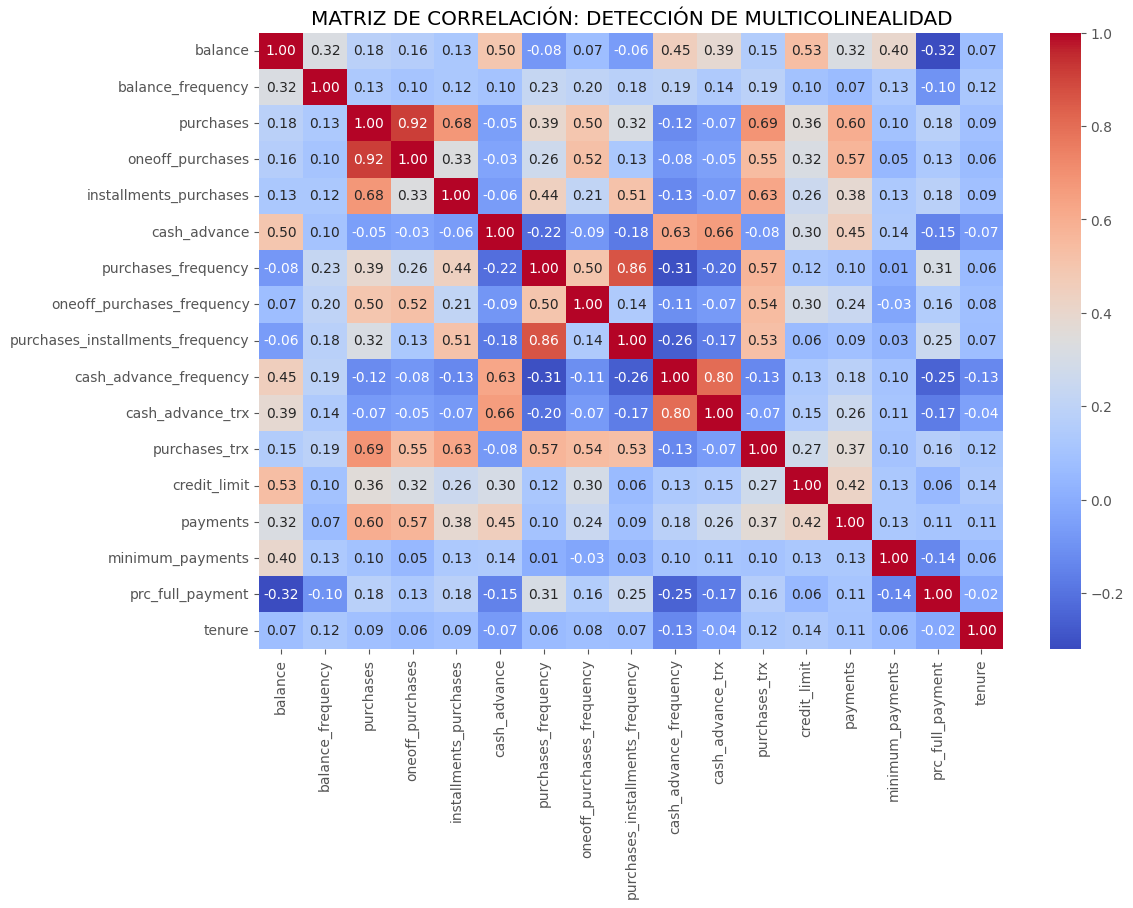


4. Elimina variables redundantes (Multicolinealidad detectada):
Columnas restantes: ['balance', 'balance_frequency', 'purchases', 'cash_advance', 'purchases_frequency', 'oneoff_purchases_frequency', 'purchases_installments_frequency', 'cash_advance_frequency', 'cash_advance_trx', 'purchases_trx', 'credit_limit', 'payments', 'minimum_payments', 'prc_full_payment', 'tenure']

5. Análisis de Sesgo (Skewness) antes de transformar:
minimum_payments                   13.85
purchases                           8.14
payments                            5.91
cash_advance_trx                    5.72
cash_advance                        5.17
purchases_trx                       4.63
balance                             2.39
prc_full_payment                    1.94
cash_advance_frequency              1.83
oneoff_purchases_frequency          1.54
credit_limit                        1.52
purchases_installments_frequency    0.51
purchases_frequency                 0.06
balance_frequency                  

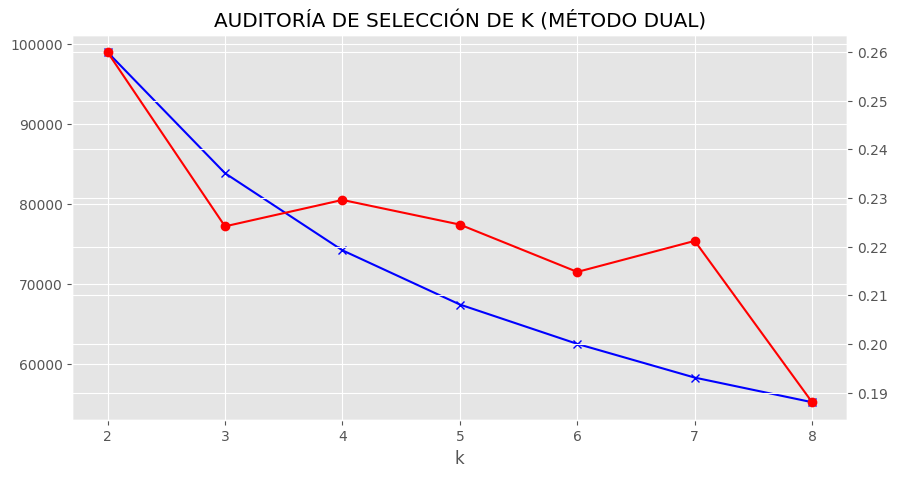


6. Perfilamiento Final (Medias por Cluster k=4):
         balance  purchases  cash_advance  credit_limit
cluster                                                
0       3,184.87   1,523.66      2,484.47      5,764.48
1       2,249.89      41.67      1,971.06      4,080.35
2       1,024.80   1,757.22         15.73      4,736.13
3          90.08     310.84         95.76      3,350.31


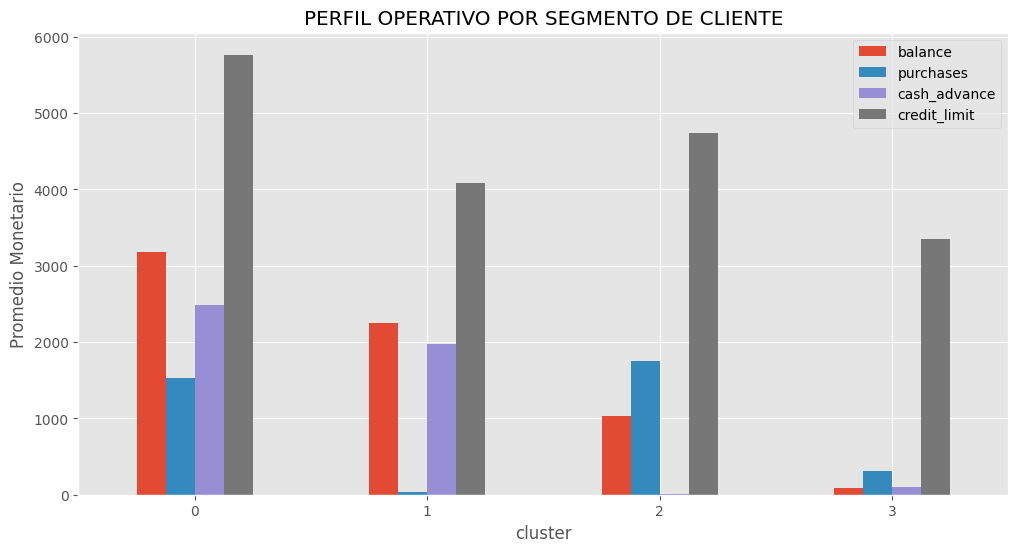

In [8]:
# =============================================================================
# PROYECTO: CLUSTERING ESTRATÉGICO DE TARJETAS DE CRÉDITO (AUDITADO)
# Alumno: Patrick
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# --- CONFIGURACIÓN TÉCNICA ---
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('ggplot')

# 1. CARGA CRÍTICA
# -----------------------------------------------------------------------------
path_base = r'C:\Users\patri\Downloads'
archivo = 'cc_general.csv'
df = pd.read_csv(os.path.join(path_base, archivo), encoding='latin1')

# Diagnóstico inicial
print("--- DIAGNÓSTICO INICIAL ---")
print(df.head())

# 2. AUDITORÍA DE VALORES NULOS
# -----------------------------------------------------------------------------
conteo_nulos = df.isnull().sum()
columnas_con_nulos = conteo_nulos[conteo_nulos > 0].index.tolist()

print("\n1. Identifica columnas con nulos:")
print(conteo_nulos[conteo_nulos > 0])

# Muestra estadísticas de las columnas afectadas para decidir la imputación
print("\n2. Análisis estadístico de columnas con nulos (describe.T):")
print(df[columnas_con_nulos].describe().T)

# Imputación por mediana (técnica elegida tras ver el sesgo en describe.T)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Verificación post-tratamiento
print("\n3. Verificación final de nulos (Post-Imputación):")
print(df[columnas_con_nulos].isnull().sum())

# 3. ANÁLISIS DE MULTICOLINEALIDAD
# -----------------------------------------------------------------------------
# Sanitiza nombres
df.columns = [col.replace('ñ', 'n').replace(' ', '_').lower() for col in df.columns]
df_model = df.drop('cust_id', axis=1)

# Calcula matriz de correlación para detectar redundancias
corr_matrix = df_model.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("MATRIZ DE CORRELACIÓN: DETECCIÓN DE MULTICOLINEALIDAD")
plt.show()

# Nota: 'purchases' tiene correlación de 0.91 con 'oneoff_purchases'. 
# Se eliminan las desagregadas para mantener la variable total.
print("\n4. Elimina variables redundantes (Multicolinealidad detectada):")
df_model = df_model.drop(['oneoff_purchases', 'installments_purchases'], axis=1)
print(f"Columnas restantes: {df_model.columns.tolist()}")

# 4. TRATAMIENTO DE SESGO (LOG TRANSFORM) Y ESCALAMIENTO
# -----------------------------------------------------------------------------
print("\n5. Análisis de Sesgo (Skewness) antes de transformar:")
print(df_model.skew().sort_values(ascending=False))

# Aplica logaritmo para normalizar distribuciones
df_log = df_model.apply(lambda x: np.log(x + 1))

# Escalamiento
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

# 5. OPTIMIZACIÓN DE CLUSTERS (ELBOW & SILHOUETTE)
# -----------------------------------------------------------------------------
wcss = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

# Gráfico dual para validación técnica
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, wcss, 'bx-', label='Inercia (Codo)')
ax1.set_xlabel('k')
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'ro-', label='Silueta')
plt.title("AUDITORÍA DE SELECCIÓN DE K (MÉTODO DUAL)")
plt.show()

# 6. MODELO FINAL Y PERFILAMIENTO (IBCS)
# -----------------------------------------------------------------------------
k_optimo = 4
df['cluster'] = KMeans(n_clusters=k_optimo, random_state=42).fit_predict(df_scaled)

print(f"\n6. Perfilamiento Final (Medias por Cluster k={k_optimo}):")
perfil = df.groupby('cluster')[['balance', 'purchases', 'cash_advance', 'credit_limit']].mean()
print(perfil)

# Visualización bajo estándares IBCS (comparación directa)
perfil.plot(kind='bar', figsize=(12, 6))
plt.title("PERFIL OPERATIVO POR SEGMENTO DE CLIENTE")
plt.ylabel("Promedio Monetario")
plt.xticks(rotation=0)
plt.show()

#### Cluster 0: "Usuarios Híbridos de Alto Riesgo/Valor"Comportamiento:
Presentan el balance más alto ($3,184.87$) y el mayor uso de adelantos en efectivo ($2,484.47$), pero también realizan compras significativas.
Insight: Es un segmento que utiliza la tarjeta para todo: compras y financiamiento líquido. Tienen el límite de crédito más alto, lo que sugiere clientes antiguos o con ingresos elevados, pero con un nivel de endeudamiento crítico.Estrategia: Monitoreo de capacidad de pago y oferta de planes de lealtad que incentiven la migración de adelantos de efectivo hacia compras en comercios.
#### Cluster 1: "Dependientes de Efectivo (Cash Seekers)"Comportamiento:
Tienen un balance elevado ($2,249.89$) y casi nula actividad de compra ($41.67$), concentrándose casi exclusivamente en el adelanto en efectivo ($1,971.06$).
Insight: Utilizan la tarjeta de crédito como un préstamo personal revolvente. No les interesa el comercio, solo la liquidez.Estrategia: Aplicar tasas de interés preferenciales en compras para intentar cambiar el hábito de uso, o alertas de riesgo por uso intensivo de cajeros automáticos.
#### Cluster 2: "Compradores Activos (Transactors)"Comportamiento:
Poseen el mayor nivel de compras ($1,757.22$) y prácticamente no utilizan adelantos en efectivo ($15.73$).
Insight: Es el cliente ideal para el procesador de pagos. Utilizan la tarjeta de forma inteligente para consumo masivo, manteniendo un balance moderado.Estrategia: Programas de cashback, puntos por compras y alianzas con comercios (retail/restaurantes) para aumentar su transaccionalidad.
#### Cluster 3: "Usuarios de Bajo Perfil o Recientes"Comportamiento:
Registran los valores más bajos en todas las categorías (Balance de $90.08$ y compras de $310.84$).
Insight: Clientes que mantienen la tarjeta "en el cajón" o que acaban de adquirirla. Tienen un límite de crédito más conservador.Estrategia: Campañas de activación mediante bonos por primera compra o incrementos graduales de línea de crédito tras un periodo de uso constante.

In [9]:
# Exporta el resultado final en UTF-8 según protocolo
ruta_salida = os.path.join(path_base, 'Analisis_Clustering_Patrick.csv')
df.to_csv(ruta_salida, index=False, encoding='utf-8')
print(f"Archivo guardado exitosamente en: {ruta_salida}")

Archivo guardado exitosamente en: C:\Users\patri\Downloads\Analisis_Clustering_Patrick.csv
